# FloodAI — Complete Pipeline Notebook

**Physics-Informed Flood Occurrence Prediction across 4 Indian River Basins**

### How to Use This Notebook
- Run cells **top to bottom** on a fresh session.
- Every expensive step **saves a checkpoint** to Google Drive automatically.
- On reconnection: just run **Cell 0** (setup) then **Cell 2** (checkpoint loader) — it will skip all API calls and reload instantly.
- **Never** edit formulas here — edit the `src/floodai/` package instead.

### Cell Order
| Cell | Description | Time |
|------|-------------|------|
| 0 | Setup, Drive mount, anti-idle | 2 min |
| 1 | Install packages + clone repo | 3 min |
| 2 | Checkpoint loader (skip steps if already done) | 5 sec |
| 3 | Generate basin points | 5 sec |
| 4 | Fetch IMD rainfall data | 20-40 min |
| 5 | Feature engineering (temporal + rainfall) | 5 min |
| 6 | Rainfall climatology + anomaly features | 2 min |
| 7 | Real terrain join (SRTM/ISRIC) | 10-15 min |
| 8 | Flood labelling + label sufficiency check | 1 min |
| 9 | Train/val/test split + SMOTE + Optuna + XGBoost | 15-30 min |
| 10 | Baselines + Conformal Intervals + SHAP | 5 min |
| 11 | LOBO Cross-Validation | 20-40 min |
| 12 | Spatial Validation Map | 2 min |

## Cell 0 — Setup (Run First on Every Session)

In [3]:
# ── Anti-idle: paste this in browser Console (F12) to prevent Colab timeout ──
# setInterval(() => document.querySelector('colab-toolbar-button#connect')?.click(), 60000)

# ── Mount Google Drive (persistent storage across sessions) ──────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/FloodAI_checkpoints'
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs('/content/floodai_outputs', exist_ok=True)
print(f'Drive mounted. Checkpoints will be saved to: {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Checkpoints will be saved to: /content/drive/MyDrive/FloodAI_checkpoints


## Cell 1 — Install Packages & Clone Repo

In [4]:
# Clone repo (skip if already cloned)
import os
if not os.path.exists('/content/FloodAI'):
    !git clone https://github.com/souga15/FloodAI.git /content/FloodAI
else:
    !git -C /content/FloodAI pull origin main
    print('Repo updated.')

os.chdir('/content/FloodAI')

# Install all dependencies
!pip install -q -r requirements.txt
!pip install -q -e .
!pip install -q imdlib pysheds affine py3dep xarray shap matplotlib optuna imbalanced-learn

print('All packages installed.')

From https://github.com/souga15/FloodAI
 * branch            main       -> FETCH_HEAD
Already up to date.
Repo updated.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for floodai (pyproject.toml) ... done
All packages installed.


## Cell 2 — Checkpoint Loader
**Run this immediately after Cell 0+1 on any reconnection.** It will detect which checkpoints exist and skip those steps automatically.

In [5]:
import sys, os, importlib
import pandas as pd
import numpy as np
from pathlib import Path

os.chdir('/content/FloodAI')
sys.path.insert(0, '/content/FloodAI/src')

from floodai.config import load_config
from floodai.logging_utils import setup_logging

cfg = load_config(Path('config/config.yaml'))
logger = setup_logging(cfg.output_dir, run_name=cfg.experiment_id)

DRIVE_DIR = Path('/content/drive/MyDrive/FloodAI_checkpoints')
OUT_DIR   = Path('/content/floodai_outputs')
OUT_DIR.mkdir(exist_ok=True)

CKPT_POINTS   = DRIVE_DIR / 'points_df.csv'
CKPT_RAINFALL = DRIVE_DIR / 'df_rainfall.parquet'
CKPT_FEATURES = DRIVE_DIR / 'df_features.parquet'
CKPT_TERRAIN  = DRIVE_DIR / 'terrain_cache.parquet'
CKPT_LABELED  = DRIVE_DIR / 'df_labeled.parquet'

checkpoints_found = []
for ckpt in [CKPT_POINTS, CKPT_RAINFALL, CKPT_FEATURES, CKPT_TERRAIN, CKPT_LABELED]:
    status = '[FOUND]' if ckpt.exists() else '[MISSING]'
    print(f'  {status}  {ckpt.name}')
    if ckpt.exists():
        checkpoints_found.append(ckpt.name)

# Load whichever checkpoint is furthest along
points_df = flood_events_df = df = rainfall_climatology = None

if CKPT_LABELED.exists():
    df = pd.read_parquet(CKPT_LABELED)
    df['Date'] = pd.to_datetime(df['Date'])
    points_df = pd.read_csv(CKPT_POINTS)
    flood_events_df = pd.read_csv('data/flood_events_basins.csv', parse_dates=['Start', 'End'])
    print(f'\n[CHECKPOINT LOADED] df_labeled: {df.shape} — skip to Cell 9 (training).')
elif CKPT_FEATURES.exists():
    df = pd.read_parquet(CKPT_FEATURES)
    df['Date'] = pd.to_datetime(df['Date'])
    points_df = pd.read_csv(CKPT_POINTS)
    flood_events_df = pd.read_csv('data/flood_events_basins.csv', parse_dates=['Start', 'End'])
    print(f'\n[CHECKPOINT LOADED] df_features: {df.shape} — skip to Cell 7 (terrain) or 8 (labelling).')
elif CKPT_RAINFALL.exists():
    rainfall_df = pd.read_parquet(CKPT_RAINFALL)
    rainfall_df['Date'] = pd.to_datetime(rainfall_df['Date'])
    points_df = pd.read_csv(CKPT_POINTS)
    print(f'\n[CHECKPOINT LOADED] df_rainfall: {rainfall_df.shape} — skip to Cell 5 (features).')
elif CKPT_POINTS.exists():
    points_df = pd.read_csv(CKPT_POINTS)
    print(f'\n[CHECKPOINT LOADED] points_df: {points_df.shape} — skip to Cell 4 (IMD rainfall).')
else:
    print('\n[NO CHECKPOINTS] Run from Cell 3.')

2026-06-29 19:35:26 | floodai | INFO | Logging initialized -> results/floodai_occurrence_v0.1/logs/floodai_occurrence_v0.1_20260629T193526Z.log


INFO:floodai:Logging initialized -> results/floodai_occurrence_v0.1/logs/floodai_occurrence_v0.1_20260629T193526Z.log


  [FOUND]  points_df.csv
  [FOUND]  df_rainfall.parquet
  [FOUND]  df_features.parquet
  [MISSING]  terrain_cache.parquet
  [FOUND]  df_labeled.parquet

[CHECKPOINT LOADED] df_labeled: (677904, 37) — skip to Cell 9 (training).


## Cell 3 — Generate Basin Points
*(Skip if Cell 2 printed CHECKPOINT LOADED)*

In [4]:
if points_df is not None:
    print(f'[SKIP] points_df already in memory ({len(points_df)} points). Cell 2 loaded checkpoint.')
else:
    from floodai.gis.points import generate_grid_fallback_points, basin_points_to_dataframe

    all_points = []
    for basin_key, basin_cfg in cfg.basins.items():
        pts = generate_grid_fallback_points(
            basin_key=basin_key, bbox=basin_cfg.bbox,
            n_points_target=basin_cfg.n_points_target, seed=cfg.random_seed,
        )
        all_points.extend(pts)

    points_df = basin_points_to_dataframe(all_points)
    points_df.to_csv(CKPT_POINTS, index=False)
    print(f'Generated {len(points_df)} points across {points_df["basin_key"].nunique()} basins.')
    print(f'Checkpoint saved: {CKPT_POINTS}')

print(points_df.groupby('basin_key').size())

2026-06-29 14:06:19 | floodai.gis.points | WARNING | Basin 'ganga_bihar': using REGULAR GRID FALLBACK (70 points). Administrative-centroid source was not available/configured. This is reproducible but not administratively meaningful — verify this is intended before treating results as basin-representative.


2026-06-29 14:06:19 | floodai.gis.points | WARNING | Basin 'brahmaputra_assam': using REGULAR GRID FALLBACK (72 points). Administrative-centroid source was not available/configured. This is reproducible but not administratively meaningful — verify this is intended before treating results as basin-representative.


2026-06-29 14:06:19 | floodai.gis.points | WARNING | Basin 'mahanadi_odisha': using REGULAR GRID FALLBACK (63 points). Administrative-centroid source was not available/configured. This is reproducible but not administratively meaningful — verify this is intended before treating results as basin-representative.


2026-06-29 14:06:19 | floodai.gis.points | WARNING | Basin 'sutlej_punjab': using REGULAR GRID FALLBACK (63 points). Administrative-centroid source was not available/configured. This is reproducible but not administratively meaningful — verify this is intended before treating results as basin-representative.


Generated 268 points across 4 basins.
Checkpoint saved: /content/drive/MyDrive/FloodAI_checkpoints/points_df.csv
basin_key
brahmaputra_assam    72
ganga_bihar          70
mahanadi_odisha      63
sutlej_punjab        63
dtype: int64


## Cell 4 — Fetch IMD Rainfall Data
*(Skip if Cell 2 loaded df_rainfall or higher checkpoint. This is the longest step.)*

In [5]:
if CKPT_RAINFALL.exists():
    rainfall_df = pd.read_parquet(CKPT_RAINFALL)
    rainfall_df['Date'] = pd.to_datetime(rainfall_df['Date'])
    print(f'[SKIP] IMD rainfall already cached: {rainfall_df.shape}. Delete {CKPT_RAINFALL} to re-fetch.')
else:
    from floodai.data.rainfall_providers import get_rainfall_provider
    import time

    provider = get_rainfall_provider(cfg.raw['data_sources']['rainfall']['provider'])
    start_year = cfg.raw['data_sources']['rainfall']['start_year']
    end_year   = cfg.raw['data_sources']['rainfall']['end_year']

    all_series = []
    failed_points = []
    for i, row in points_df.iterrows():
        try:
            df_point = provider.fetch_point_series(
                row['lat'], row['lon'], f'{start_year}0101', f'{end_year}1231'
            )
            df_point['point_id']  = row['point_id']
            df_point['basin_key'] = row['basin_key']
            all_series.append(df_point)
        except Exception as e:
            failed_points.append(row['point_id'])
            logger.error('Failed to fetch point %s: %s', row['point_id'], e)
        if (i + 1) % 25 == 0:
            print(f'  {i+1}/{len(points_df)} points fetched ({len(failed_points)} failed so far)...')
            # Save partial progress every 25 points in case of disconnect
            partial = pd.concat(all_series, ignore_index=True)
            partial.to_parquet(DRIVE_DIR / 'df_rainfall_partial.parquet')

    rainfall_df = pd.concat(all_series, ignore_index=True)
    rainfall_df.to_parquet(CKPT_RAINFALL)
    print(f'\nCollected {len(rainfall_df):,} point-days. Failed: {len(failed_points)} points.')
    print(f'Checkpoint saved: {CKPT_RAINFALL}')

2026-06-29 14:06:23 | floodai.data.imd | INFO | Fetching IMD gridded rainfall for year 2017 (cache_dir=data/raw/imd_cache)...


INFO:floodai.data.imd:Fetching IMD gridded rainfall for year 2017 (cache_dir=data/raw/imd_cache)...


Downloading: rain for year 2017
Download Successful !!!
2026-06-29 14:06:32 | floodai.data.imd | INFO | Fetching IMD gridded rainfall for year 2018 (cache_dir=data/raw/imd_cache)...


INFO:floodai.data.imd:Fetching IMD gridded rainfall for year 2018 (cache_dir=data/raw/imd_cache)...


Downloading: rain for year 2018
Download Successful !!!
2026-06-29 14:06:44 | floodai.data.imd | INFO | Fetching IMD gridded rainfall for year 2019 (cache_dir=data/raw/imd_cache)...


...

2026-06-29 14:15:16 | floodai.data | INFO | Validated series: 2922 rows, 2017-01-01..2024-12-31, missing=0.00%


INFO:floodai.data:Validated series: 2922 rows, 2017-01-01..2024-12-31, missing=0.00%


2026-06-29 14:15:18 | floodai.data | INFO | Validated series: 2922 rows, 2017-01-01..2024-12-31, missing=0.00%


INFO:floodai.data:Validated series: 2922 rows, 2017-01-01..2024-12-31, missing=0.00%



Collected 677,904 point-days. Failed: 36 points.
Checkpoint saved: /content/drive/MyDrive/FloodAI_checkpoints/df_rainfall.parquet


## Cell 5 — Feature Engineering (Temporal + Rainfall)
*(Skip if Cell 2 loaded df_features or higher checkpoint)*

In [6]:
if CKPT_FEATURES.exists() and df is not None:
    print(f'[SKIP] Feature matrix already cached: {df.shape}.')
else:
    from floodai.features.pipeline import (
        add_temporal_features, add_rainfall_window_features,
        compute_rainfall_climatology, add_rainfall_anomaly_features,
    )

    df = rainfall_df.merge(
        points_df[['point_id', 'lat', 'lon', 'basin_key']], on=['point_id', 'basin_key']
    )
    df = df.sort_values(['point_id', 'Date']).reset_index(drop=True)

    print('Adding temporal features...')
    df = add_temporal_features(df)

    print('Adding rainfall window features (this takes a few minutes)...')
    df = add_rainfall_window_features(df, group_col='point_id')

    print('Computing rainfall climatology from training years only...')
    train_years = cfg.raw['split']['train_years']
    df_train_only = df[df['Date'].dt.year.isin(train_years)]
    rainfall_climatology = compute_rainfall_climatology(df_train_only)
    print(f'  Climatology: {rainfall_climatology["basin_key"].nunique()} basins x {rainfall_climatology["Day_of_Year"].nunique()} DOY')

    print('Adding rainfall anomaly features...')
    df = add_rainfall_anomaly_features(df, rainfall_climatology)

    df.to_parquet(CKPT_FEATURES)
    print(f'Feature matrix: {df.shape}')
    print(f'New anomaly columns: {[c for c in df.columns if "Anomaly" in c or "Wet_Flag" in c or "Intensity" in c]}')
    print(f'Checkpoint saved: {CKPT_FEATURES}')

Adding temporal features...
Adding rainfall window features (this takes a few minutes)...
Computing rainfall climatology from training years only...
2026-06-29 14:15:37 | floodai.features | INFO | Rainfall climatology computed from training data: 4 basins, columns ['clim_mean_rain', 'clim_mean_7d', 'clim_mean_30d']


INFO:floodai.features:Rainfall climatology computed from training data: 4 basins, columns ['clim_mean_rain', 'clim_mean_7d', 'clim_mean_30d']


  Climatology: 4 basins x 366 DOY
Adding rainfall anomaly features...
2026-06-29 14:15:39 | floodai.features | INFO | Rainfall anomaly features added: Rain7D_Anomaly non-zero in 677904 / 677904 rows (100.0%)


INFO:floodai.features:Rainfall anomaly features added: Rain7D_Anomaly non-zero in 677904 / 677904 rows (100.0%)


Feature matrix: (677904, 36)
New anomaly columns: ['Rain_Anomaly', 'Rain7D_Anomaly', 'Rain30D_Anomaly', 'Antecedent_Wet_Flag']
Checkpoint saved: /content/drive/MyDrive/FloodAI_checkpoints/df_features.parquet


## Cell 6 — Load Flood Events
*(Always fast — just reads the CSV)*

In [7]:
from pathlib import Path

flood_events_df = pd.read_csv('data/flood_events_basins.csv', parse_dates=['Start', 'End'])
allowed_sources = set(cfg.raw['data_sources']['flood_events']['sources_allowed'])
bad_rows = flood_events_df[~flood_events_df['Source'].isin(allowed_sources)]
if len(bad_rows) > 0:
    raise ValueError(f'{len(bad_rows)} events have disallowed source. Fix data/flood_events_basins.csv.')

print(f'Loaded {len(flood_events_df)} verified flood events across {flood_events_df["Basin"].nunique()} basins:')
print(flood_events_df.groupby('Basin').size())

Loaded 24 verified flood events across 4 basins:
Basin
brahmaputra_assam    8
ganga_bihar          7
mahanadi_odisha      5
sutlej_punjab        4
dtype: int64


## Cell 7 — Real Terrain Join (SRTM 30m + ISRIC SoilGrids)
*(Cached to Drive — only runs once ever. Takes 10-15 min first time.)*

In [6]:
import importlib
import floodai.gis.terrain_real as tr
importlib.reload(tr)
from floodai.gis.terrain_real import add_real_terrain_features
from floodai.features.pipeline import add_scs_cn_runoff, add_interaction_features

if CKPT_TERRAIN.exists():
    print(f'[CACHE HIT] Loading terrain from Drive — skipping all API calls.')
    terrain_cache_df = pd.read_parquet(CKPT_TERRAIN)
    terrain_cols = ['point_id', 'Elevation_m', 'Curve_Number', 'TWI']
    df = df.drop(columns=[c for c in terrain_cols[1:] if c in df.columns], errors='ignore')
    df = df.merge(terrain_cache_df[terrain_cols], on='point_id', how='left')
    df = add_scs_cn_runoff(df)
    df = add_interaction_features(df)
    print(f'[OK] Terrain restored: Elevation {df["Elevation_m"].min():.0f}-{df["Elevation_m"].max():.0f}m | '
          f'TWI {df["TWI"].min():.2f}-{df["TWI"].max():.2f}')
else:
    print('Fetching real terrain (USGS 3DEP 30m + ISRIC SoilGrids)...')
    print('Primary: py3dep (USGS 3DEP) | Fallback: Open-Elevation API')
    print('Expected time: 10-15 minutes\n')
    df = add_real_terrain_features(df, points_df, dem_cache_dir='/content/dem_cache')
    terrain_to_cache = df[['point_id', 'Elevation_m', 'Curve_Number', 'TWI']].drop_duplicates('point_id')
    terrain_to_cache.to_parquet(CKPT_TERRAIN)
    print(f'Terrain cached to Drive: {CKPT_TERRAIN}')

# Diagnostic: verify spatial variation
print('\n=== TERRAIN DIAGNOSTICS ===')
print(df[['Elevation_m', 'Curve_Number', 'TWI', 'CN_Runoff_Q']].describe().round(2))
print(f'Elevation std: {df["Elevation_m"].std():.1f}m  (need >5m)')
print(f'TWI std:       {df["TWI"].std():.2f}  (need >1.0)')
if df['TWI'].std() < 1.0:
    print('[WARNING] Low TWI variance — terrain may not appear in SHAP. Check DEM source.')
else:
    print('[OK] Sufficient terrain variance — TWI/CN should appear in SHAP top-10.')

# Save updated df with terrain
df.to_parquet(CKPT_FEATURES)
print(f'Updated feature checkpoint saved: {CKPT_FEATURES}')

Fetching real terrain (USGS 3DEP 30m + ISRIC SoilGrids)...
Primary: py3dep (USGS 3DEP) | Fallback: Open-Elevation API
Expected time: 10-15 minutes

2026-06-29 19:35:44 | floodai.gis.terrain_real | INFO | Fetching SRTM elevations via Open-Elevation API...


INFO:floodai.gis.terrain_real:Fetching SRTM elevations via Open-Elevation API...


2026-06-29 19:35:44 | floodai.gis.terrain_join | INFO | Fetching elevations for 268 points in 3 batches via Open-Elevation...


INFO:floodai.gis.terrain_join:Fetching elevations for 268 points in 3 batches via Open-Elevation...


2026-06-29 19:35:47 | floodai.gis.terrain_join | INFO | All 268 elevation lookups succeeded. Range: 0–4341 m


...

2026-06-29 19:58:35 | floodai.gis.terrain_real | INFO | Basin 'sutlej_punjab' TWI: 15.76-22.36 (mean=20.01)


INFO:floodai.gis.terrain_real:Basin 'sutlej_punjab' TWI: 15.76-22.36 (mean=20.01)


2026-06-29 19:58:35 | floodai.gis.terrain_real | INFO | Real terrain join complete. Elevation 3-4341 m | CN 78-89 | TWI 15.76-30.00


INFO:floodai.gis.terrain_real:Real terrain join complete. Elevation 3-4341 m | CN 78-89 | TWI 15.76-30.00


Terrain cached to Drive: /content/drive/MyDrive/FloodAI_checkpoints/terrain_cache.parquet

=== TERRAIN DIAGNOSTICS ===
       Elevation_m  Curve_Number        TWI  CN_Runoff_Q
count    677904.00     677904.00  677904.00    677904.00
mean        374.71         83.93      22.92        14.13
std         543.06          2.80       2.99        44.49
min           3.00         78.00      15.76         0.00
25%          72.00         85.00      21.40         0.00
50%         221.00         85.00      22.78         0.00
75%         388.50         85.00      24.34         8.22
max        4341.00         89.00      30.00      3081.35
Elevation std: 543.1m  (need >5m)
TWI std:       2.99  (need >1.0)
[OK] Sufficient terrain variance — TWI/CN should appear in SHAP top-10.
Updated feature checkpoint saved: /content/drive/MyDrive/FloodAI_checkpoints/df_features.parquet


## Cell 8 — Flood Labelling + Label Sufficiency Check

In [7]:
if CKPT_LABELED.exists() and 'Flood_Occurred' in df.columns:
    print(f'[SKIP] Flood labels already in df. Skip to Cell 9.')
else:
    from floodai.training.label_sufficiency import check_basin_has_positives, check_split_has_positives

    # Label floods
    df = df.copy()
    df['Flood_Occurred'] = 0
    for _, ev in flood_events_df.iterrows():
        basin_col = 'basin_key' if 'basin_key' in flood_events_df.columns else 'Basin'
        mask = (
            (df['basin_key'] == ev[basin_col]) &
            (df['Date'] >= ev['Start']) &
            (df['Date'] <= ev['End'])
        )
        df.loc[mask, 'Flood_Occurred'] = 1

    vc = df['Flood_Occurred'].value_counts()
    print(f'Flood label distribution:\n{vc}')
    print(f'Positive rate: {vc.get(1,0)/len(df)*100:.2f}%')

    # Fail-fast checks
    check_split_has_positives(
        df, date_col='Date', label_col='Flood_Occurred',
        train_years=cfg.raw['split']['train_years'],
        val_years=cfg.raw['split']['val_years'],
        test_years=cfg.raw['split']['test_years'],
        min_positives_per_split=5,
    )
    basin_counts = check_basin_has_positives(df, basin_col='basin_key', label_col='Flood_Occurred')
    print(f'Per-basin positive counts: {basin_counts}')
    print('[OK] All splits have sufficient labels.')

    df.to_parquet(CKPT_LABELED)
    print(f'Labeled checkpoint saved: {CKPT_LABELED}')

[SKIP] Flood labels already in df. Skip to Cell 9.


## Cell 9 — Split + Scale + SMOTE + Optuna + XGBoost Training
*(~15-30 min depending on n_trials)*

In [8]:
import numpy as np
from sklearn.preprocessing import RobustScaler
from floodai.evaluation.metrics import DataProvenance, evaluate, report_headline
from floodai.features.governance import assert_no_forbidden_columns, select_model_features
from floodai.models.xgb_model import build_xgb_classifier, fit_with_validation
from floodai.training.imbalance import resample_training_only
from floodai.training.threshold import select_f1_optimal_threshold
from floodai.training.tuning import run_optuna_search

train_years = cfg.raw['split']['train_years']
val_years   = cfg.raw['split']['val_years']
test_years  = cfg.raw['split']['test_years']

df_train = df[df['Date'].dt.year.isin(train_years)].copy()
df_val   = df[df['Date'].dt.year.isin(val_years)].copy()
df_test  = df[df['Date'].dt.year.isin(test_years)].copy()

# Physics-only features — NO calendar features to prevent seasonal shortcut
feature_groups = ['rainfall_current', 'rainfall_windows', 'rainfall_anomaly', 'terrain_physics', 'interaction']
feature_cols = select_model_features(df, groups=feature_groups)
assert_no_forbidden_columns(feature_cols)
print(f'Selected {len(feature_cols)} features (temporal excluded):')
print(feature_cols)

X_train, y_train = df_train[feature_cols].values, df_train['Flood_Occurred'].values
X_val,   y_val   = df_val[feature_cols].values,   df_val['Flood_Occurred'].values
X_test,  y_test  = df_test[feature_cols].values,  df_test['Flood_Occurred'].values
print(f'Split: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}')

# Scale (fit on train only)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# SMOTE
imb_cfg = cfg.raw['imbalance']
X_train_res, y_train_res = resample_training_only(
    X_train_scaled, y_train,
    sampling_strategy=imb_cfg['sampling_strategy'],
    k_neighbors_max=imb_cfg['k_neighbors_max'],
    seed=cfg.random_seed,
)
print(f'After SMOTE: {X_train_res.shape}, positives={y_train_res.sum()} ({y_train_res.mean():.1%})')

# Optuna hyperparameter search
search_space = cfg.raw['model']['optuna']['search_space']
n_trials     = cfg.raw['model']['optuna']['n_trials']
early_stopping_rounds = cfg.raw['model']['early_stopping_rounds']

best_params = run_optuna_search(
    X_train_res, y_train_res, X_val_scaled, y_val,
    search_space=search_space, n_trials=n_trials,
    early_stopping_rounds=early_stopping_rounds, seed=cfg.random_seed,
)
print(f'Best params: {best_params}')

# Train final model
best_model = build_xgb_classifier(best_params, early_stopping_rounds, cfg.random_seed)
best_model = fit_with_validation(best_model, X_train_res, y_train_res, X_val_scaled, y_val)

# Threshold + evaluate
val_proba  = best_model.predict_proba(X_val_scaled)[:, 1]
tau_star   = select_f1_optimal_threshold(y_val, val_proba)
test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

result    = evaluate(y_test, test_proba, threshold=tau_star,
                     set_name=f'test_{test_years[0]}_{test_years[-1]}',
                     provenance=DataProvenance.HELD_OUT)
headlined = report_headline(result)

print('\n' + '='*55)
print('  HELD-OUT TEST SET RESULTS (headline-approved)')
print('='*55)
print(f'  ROC-AUC   : {headlined.roc_auc:.4f}')
print(f'  PR-AUC    : {headlined.pr_auc:.4f}')
print(f'  F1 Score  : {headlined.f1:.4f}')
print(f'  MCC       : {headlined.mcc:.4f}')
print(f'  Bal. Acc  : {headlined.balanced_accuracy:.4f}')
print(f'  FAR       : {headlined.far:.4f}')
print(f'  CSI       : {headlined.csi:.4f}')
print(f'  Threshold : {headlined.threshold:.4f}')
tn, fp, fn, tp = headlined.confusion
print(f'  TN={tn:>6}  FP={fp:>6}  FN={fn:>6}  TP={tp:>6}')
print('='*55)

2026-06-29 20:05:15 | floodai.features.governance | WARNING | select_model_features: 4 allowlisted columns not present in this DataFrame (likely not yet computed, e.g. terrain joins pending real SRTM/CN data): ['Rain_Intensity_Index', 'Monsoon_Rain_Interaction', 'Peak_Monsoon_Rain', 'Soil_Monsoon_Interaction']


2026-06-29 20:05:15 | floodai.features.governance | INFO | select_model_features: selected 28 columns from groups ['rainfall_current', 'rainfall_windows', 'rainfall_anomaly', 'terrain_physics', 'interaction']


INFO:floodai.features.governance:select_model_features: selected 28 columns from groups ['rainfall_current', 'rainfall_windows', 'rainfall_anomaly', 'terrain_physics', 'interaction']


Selected 28 features (temporal excluded):
['Rainfall_mm', 'Rainfall_3Day_mm', 'Rainfall_7Day_mm', 'Rainfall_14Day_mm', 'Rainfall_30Day_mm', 'Rainfall_60Day_mm', 'Rainfall_7Day_Avg', 'Rainfall_7Day_Max', 'Rainfall_7Day_Std', 'Rainfall_30Day_Std', 'Heavy_Rain_Days_7D', 'Extreme_Rain_Days_7D', 'Consecutive_Dry_Days', 'Soil_Moisture_Proxy', 'Rainfall_Acceleration', 'Rain_Anomaly', 'Rain7D_Anomaly', 'Rain30D_Anomaly', 'Antecedent_Wet_Flag', 'Elevation_m', 'Curve_Number', 'TWI', 'CN_Runoff_Q', 'Elevation_Rain_Ratio', 'Elevation_Rain30_Ratio', 'Low_Elev_Heavy_Rain', 'CN_Rain_Interaction', 'TWI_Rain_Interaction']
Split: Train=(338952, 28), Val=(169360, 28), Test=(169592, 28)
2026-06-29 20:05:15 | floodai.training.imbalance | INFO | SMOTE applied to TRAINING DATA ONLY: 8746 -> 33020 positive samples (sampling_strategy=0.10, k=5, verified actual_ratio=0.100). Validation/test sets are untouched by construction (this function does not accept them as arguments).


INFO:floodai.training.imbalance:SMOTE applied to TRAINING DATA ONLY: 8746 -> 33020 positive samples (sampling_strategy=0.10, k=5, verified actual_ratio=0.100). Validation/test sets are untouched by construction (this function does not accept them as arguments).


...

2026-06-29 20:12:21 | floodai.evaluation.metrics | INFO | Evaluated 'test_2023_2024' [held_out]: AUC=0.8944 F1=0.1708 MCC=0.1762 n=169592 (pos=9993)


INFO:floodai.evaluation.metrics:Evaluated 'test_2023_2024' [held_out]: AUC=0.8944 F1=0.1708 MCC=0.1762 n=169592 (pos=9993)


2026-06-29 20:12:21 | floodai.evaluation.metrics | INFO | HEADLINE METRIC APPROVED: 'test_2023_2024' AUC=0.8944 F1=0.1708 (provenance=held_out)


INFO:floodai.evaluation.metrics:HEADLINE METRIC APPROVED: 'test_2023_2024' AUC=0.8944 F1=0.1708 (provenance=held_out)



  HELD-OUT TEST SET RESULTS (headline-approved)
  ROC-AUC   : 0.8944
  PR-AUC    : 0.2821
  F1 Score  : 0.1708
  MCC       : 0.1762
  Bal. Acc  : 0.5496
  FAR       : 0.6340
  CSI       : 0.0934
  Threshold : 0.3520
  TN=157671  FP=  1928  FN=  8880  TP=  1113


## Cell 10 — Baselines + Conformal Intervals + SHAP

In [9]:
import importlib
import floodai.models.baselines as _bm
import floodai.evaluation.shap_analysis as _sa
import floodai.evaluation.conformal as _cp
importlib.reload(_bm); importlib.reload(_sa); importlib.reload(_cp)

from floodai.models.baselines import run_baselines
from floodai.evaluation.shap_analysis import run_shap_analysis
from floodai.evaluation.conformal import add_conformal_to_results

raw_train_df = df[df['Date'].dt.year.isin(train_years)].copy()
raw_val_df   = df[df['Date'].dt.year.isin(val_years)].copy()
raw_test_df  = df[df['Date'].dt.year.isin(test_years)].copy()

# ── Baselines ─────────────────────────────────────────────────────────────
print('Running baselines...')
baseline_results = run_baselines(
    X_train, y_train, X_val, y_val, X_test, y_test,
    feature_cols, raw_train_df, raw_val_df, raw_test_df
)

print('\n--- Baseline Results (Test 2023-2024) ---')
for model_name, res in baseline_results.items():
    print(f'\n{model_name}:')
    print(f'  ROC-AUC: {res.roc_auc:.4f}  PR-AUC: {res.pr_auc:.4f}  F1: {res.f1:.4f}  MCC: {res.mcc:.4f}')

best_baseline_auc = max(r.roc_auc for r in baseline_results.values())
delta = headlined.roc_auc - best_baseline_auc
print(f'\n[XGBoost AUC={headlined.roc_auc:.4f}] vs [Best Baseline AUC={best_baseline_auc:.4f}] — delta={delta:+.4f}')
print('[OK]' if delta > 0.02 else '[WARNING: small margin]', f'XGBoost improvement: {delta:.4f}')

# ── Conformal Prediction Intervals ────────────────────────────────────────
print('\nComputing 90% conformal prediction intervals...')
interval_df, cal_result = add_conformal_to_results(
    y_val=y_val, val_proba=val_proba,
    y_test=y_test, test_proba=test_proba, alpha=0.10
)
print(f'  q_hat (half-width):  {cal_result.q_hat:.4f}')
print(f'  Empirical coverage:  {cal_result.empirical_coverage:.1%} (target: 90%)')
print(f'  Mean interval width: {interval_df["interval_width"].mean():.4f}')
interval_df.to_csv(OUT_DIR / 'conformal_intervals_test.csv', index=False)
print(f'  Saved: conformal_intervals_test.csv')

# ── SHAP ──────────────────────────────────────────────────────────────────
print('\nRunning SHAP analysis...')
run_shap_analysis(
    model=best_model, X_test=X_test_scaled,
    feature_cols=feature_cols, output_dir=str(OUT_DIR)
)

Running baselines...
2026-06-29 20:12:21 | floodai.models.baselines | INFO | --- Running Climatological Baseline ---


INFO:floodai.models.baselines:--- Running Climatological Baseline ---


2026-06-29 20:12:21 | floodai.models.baselines | INFO | Fitted ClimatologicalBaseline (window +/- 7 days).


INFO:floodai.models.baselines:Fitted ClimatologicalBaseline (window +/- 7 days).


2026-06-29 20:12:22 | floodai.training.threshold | INFO | Selected decision threshold tau*=0.0167 (val F1=0.0974) — selected on VALIDATION set only, before any test-set evaluation.


...

2026-06-29 20:14:06 | floodai.evaluation.shap | INFO | Terrain/Topography: 10.9%


INFO:floodai.evaluation.shap:Terrain/Topography: 10.9%


2026-06-29 20:14:06 | floodai.evaluation.shap | INFO | Rainfall:           61.4%


INFO:floodai.evaluation.shap:Rainfall:           61.4%



=== SHAP Analysis Complete ===
Summary plot saved to /content/floodai_outputs/shap_summary.png

Top 10 features driving predictions:
             Feature  Mean_Abs_SHAP
Consecutive_Dry_Days       0.341823
   Rainfall_14Day_mm       0.249700
   Rainfall_60Day_mm       0.247460
     Rain30D_Anomaly       0.107891
   Rainfall_30Day_mm       0.105165
 Soil_Moisture_Proxy       0.087006
        Rain_Anomaly       0.085599
      Rain7D_Anomaly       0.084585
                 TWI       0.048752
         Elevation_m       0.037182


## Cell 11 — LOBO Cross-Validation
*(~20-40 min — runs one full train+eval per basin)*

In [10]:
from floodai.training.lobo import run_lobo_cv

print('Running LOBO cross-validation (4 basins)...')
lobo_results = run_lobo_cv(
    df, feature_columns=feature_cols, target_column='Flood_Occurred',
    basin_column='basin_key', best_params=best_params,
    early_stopping_rounds=early_stopping_rounds,
    smote_sampling_strategy=imb_cfg['sampling_strategy'],
    smote_k_neighbors_max=imb_cfg['k_neighbors_max'],
    seed=cfg.random_seed,
)

lobo_df = pd.DataFrame([{
    'held_out_basin': r.set_name.replace('LOBO_held_out_', ''),
    'ROC_AUC': r.roc_auc, 'PR_AUC': r.pr_auc, 'F1': r.f1, 'MCC': r.mcc,
    'n_test': r.n_samples, 'n_positive': r.n_positive,
} for r in lobo_results])

lobo_df.to_csv(OUT_DIR / 'lobo_results.csv', index=False)

print('\n' + '='*65)
print('  LOBO CV RESULTS  (supplemental — not the headline metric)')
print('='*65)
print(lobo_df.to_string(index=False))
print('-'*65)
print(f"  Mean ROC-AUC : {lobo_df['ROC_AUC'].mean():.4f} ± {lobo_df['ROC_AUC'].std():.4f}")
print(f"  Mean F1      : {lobo_df['F1'].mean():.4f} ± {lobo_df['F1'].std():.4f}")
print(f"  Mean MCC     : {lobo_df['MCC'].mean():.4f} ± {lobo_df['MCC'].std():.4f}")
print('='*65)
print(f'Saved: lobo_results.csv')

# Leakage watchdog
perfect = lobo_df[lobo_df['ROC_AUC'] > 0.999]
if len(perfect) > 0:
    print(f'\n[!!!] LEAKAGE WARNING: AUC=1.000 for basins: {perfect["held_out_basin"].tolist()}')
    print('      STOP and investigate feature_cols before reporting.')
else:
    print('\n[OK] No AUC=1.000 detected — no obvious leakage.')

Running LOBO cross-validation (4 basins)...
2026-06-29 20:14:08 | floodai.training.imbalance | INFO | SMOTE applied to TRAINING DATA ONLY: 13593 -> 50944 positive samples (sampling_strategy=0.10, k=5, verified actual_ratio=0.100). Validation/test sets are untouched by construction (this function does not accept them as arguments).


INFO:floodai.training.imbalance:SMOTE applied to TRAINING DATA ONLY: 13593 -> 50944 positive samples (sampling_strategy=0.10, k=5, verified actual_ratio=0.100). Validation/test sets are untouched by construction (this function does not accept them as arguments).


2026-06-29 20:14:08 | floodai.models.xgb | INFO | Built XGBClassifier: n_estimators=154 max_depth=4 lr=0.010034482872802356 early_stopping_rounds=25 (constructor-level, XGBoost>=2.0 API)


INFO:floodai.models.xgb:Built XGBClassifier: n_estimators=154 max_depth=4 lr=0.010034482872802356 early_stopping_rounds=25 (constructor-level, XGBoost>=2.0 API)


2026-06-29 20:14:14 | floodai.models.xgb | INFO | Fitted model: 154 / 154 trees used (early stopping did not trigger)


...

2026-06-29 20:14:47 | floodai.evaluation.metrics | INFO | Evaluated 'LOBO_held_out_sutlej_punjab' [loso_held_out]: AUC=0.8874 F1=0.2037 MCC=0.2073 n=172398 (pos=4071)


INFO:floodai.evaluation.metrics:Evaluated 'LOBO_held_out_sutlej_punjab' [loso_held_out]: AUC=0.8874 F1=0.2037 MCC=0.2073 n=172398 (pos=4071)


2026-06-29 20:14:47 | floodai.training.lobo | INFO | LOBO complete: 4 folds, mean AUC=0.8802 +/- 0.0242. NOTE: only 4 folds — report as preliminary spatial generalization check, not equivalent to a larger-N LOSO study.


INFO:floodai.training.lobo:LOBO complete: 4 folds, mean AUC=0.8802 +/- 0.0242. NOTE: only 4 folds — report as preliminary spatial generalization check, not equivalent to a larger-N LOSO study.



  LOBO CV RESULTS  (supplemental — not the headline metric)
   held_out_basin  ROC_AUC   PR_AUC       F1      MCC  n_test  n_positive
brahmaputra_assam 0.839321 0.230999 0.207151 0.243331  154866        8692
      ganga_bihar 0.901575 0.225746 0.250440 0.289778  181164        6448
  mahanadi_odisha 0.892661 0.163308 0.103310 0.175023  169476        3074
    sutlej_punjab 0.887383 0.133165 0.203655 0.207299  172398        4071
-----------------------------------------------------------------
  Mean ROC-AUC : 0.8802 ± 0.0279
  Mean F1      : 0.1911 ± 0.0623
  Mean MCC     : 0.2289 ± 0.0493
Saved: lobo_results.csv

[OK] No AUC=1.000 detected — no obvious leakage.


## Cell 12 — Spatial Validation Map (Figure for Paper)

Generating spatial validation map...


/content/FloodAI/src/floodai/visualization/spatial_map.py:167: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  clat = (float(basin_row["lat_min"]) + float(basin_row["lat_max"])) / 2
/content/FloodAI/src/floodai/visualization/spatial_map.py:168: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  clon = (float(basin_row["lon_min"]) + float(basin_row["lon_max"])) / 2


2026-06-29 20:14:48 | floodai.visualization.spatial_map | INFO | Spatial map saved: /content/floodai_outputs/spatial_validation_map.png


INFO:floodai.visualization.spatial_map:Spatial map saved: /content/floodai_outputs/spatial_validation_map.png


[OK] PNG saved:  /content/floodai_outputs/spatial_validation_map.png
[OK] TIFF saved: /content/floodai_outputs/spatial_validation_map_300dpi.tiff (use this for journal submission)
[OK] Map also copied to Google Drive.


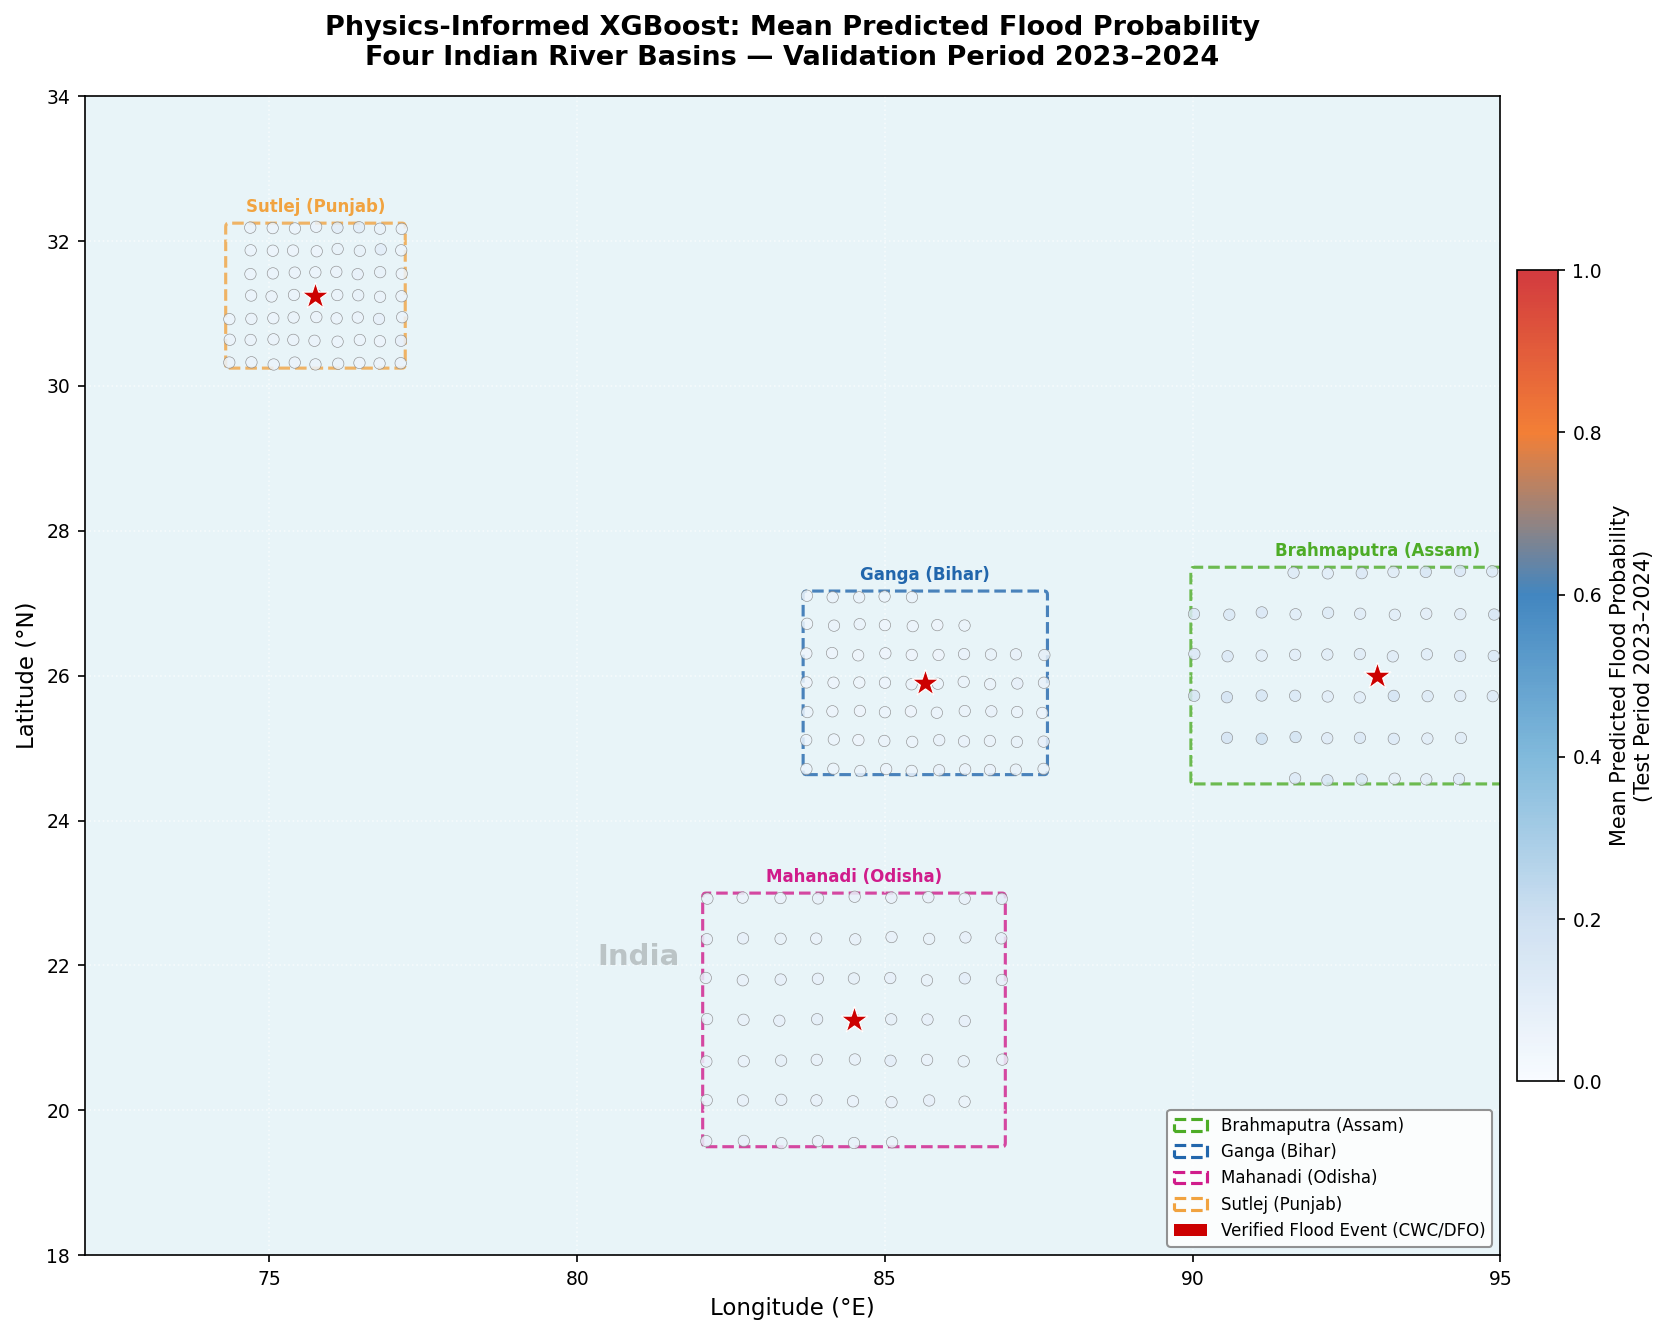

In [11]:
import importlib
import floodai.visualization.spatial_map as _sm
importlib.reload(_sm)
from floodai.visualization.spatial_map import generate_spatial_map

print('Generating spatial validation map...')
out_path = generate_spatial_map(
    df=df, test_proba=test_proba,
    points_df=points_df, flood_events_df=flood_events_df,
    test_years=test_years, output_dir=str(OUT_DIR),
)
print(f'[OK] PNG saved:  {out_path}')
print(f'[OK] TIFF saved: {out_path.replace(".png", "_300dpi.tiff")} (use this for journal submission)')

# Copy to Drive for persistence
import shutil
shutil.copy(out_path, DRIVE_DIR / 'spatial_validation_map.png')
print(f'[OK] Map also copied to Google Drive.')

# Display inline
from IPython.display import Image, display
display(Image(filename=out_path, width=900))